In [27]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from QiskitTranspiler.transpiler.transpile import transpile, apply_layout
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from QiskitTranspiler.transpiler.passes.optimization.optimization import optimize

In [18]:
def transpile_with_mapping(qc, backend):
    coupling_map = backend.coupling_map
    circuit = qc
    # print(coupling_map)

    INFRASTRUCTURE_GATES = { "measure", "delay", "reset"}
    CONTROL_FLOW_GATES = {"if_else", "for_loop", "switch_case", "while_loop", "break", "continue"}

    basis_gates = [
        g for g in backend.operation_names 
        if g not in INFRASTRUCTURE_GATES and g not in CONTROL_FLOW_GATES
    ]

    # print("Basis gates:", basis_gates)

    layout_no_translate, mapping = Layout.run_layout(circuit, backend)

    layout_no_translate = translate_circuit(layout_no_translate, basis=basis_gates)

    layout_no_translate = optimize(layout_no_translate)

    return layout_no_translate, mapping

In [7]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

#Testing first with a simulator, then with a real backend
backend = FakeFez()



In [21]:
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
import numpy as np

def verify_equivalence(original_qc, routed_qc, mapping):
    """
    Verify that routed_qc is functionally equivalent to original_qc
    up to the qubit permutation defined by mapping.
    mapping: dict {virtual: physical}
    """
    sim = AerSimulator(method='statevector')

    # get statevector of original (no measurements)
    orig_no_meas = original_qc.remove_final_measurements(inplace=False)
    orig_no_meas.save_statevector()
    sv_orig = Statevector(sim.run(orig_no_meas).result().get_statevector())

    # get statevector of routed (no measurements)
    routed_no_meas = routed_qc.remove_final_measurements(inplace=False)
    routed_no_meas.save_statevector()
    sv_routed = Statevector(sim.run(routed_no_meas).result().get_statevector())

    # build the permutation: where did each physical qubit end up?
    n = original_qc.num_qubits
    perm = [mapping[v] for v in range(n)]

    # apply inverse permutation to routed statevector
    # sv_routed_permuted = sv_routed.permute(perm)

    # compare up to global phase
    return sv_orig, sv_routed

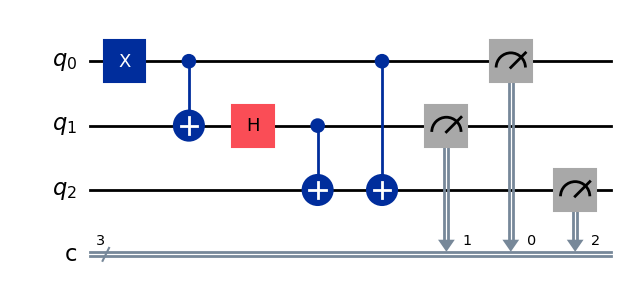

In [33]:
qc = QuantumCircuit(3, 3)
qc.x(0)
qc.cx(0, 1)
qc.h(1)
qc.cx(1, 2)
qc.cx(0, 2)
qc.measure([0, 1, 2], [0, 1, 2])
qc.draw("mpl")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


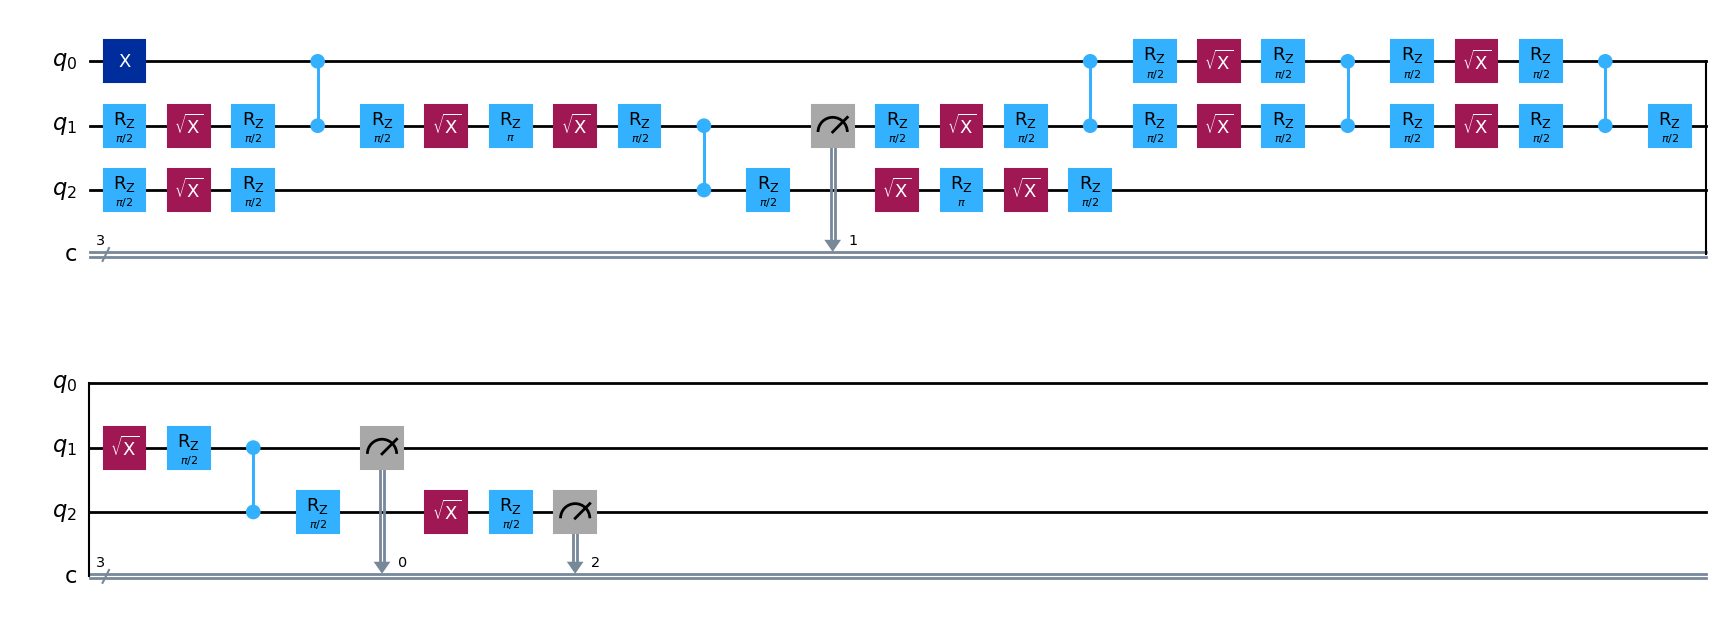

In [32]:
tqc, mapping = transpile_with_mapping(qc, backend)
tqc.draw("mpl")

In [34]:
sv1, sv2 = verify_equivalence(qc, tqc, mapping)
sv1.draw("latex")

<IPython.core.display.Latex object>

In [36]:
sv2.draw("latex")

<IPython.core.display.Latex object>

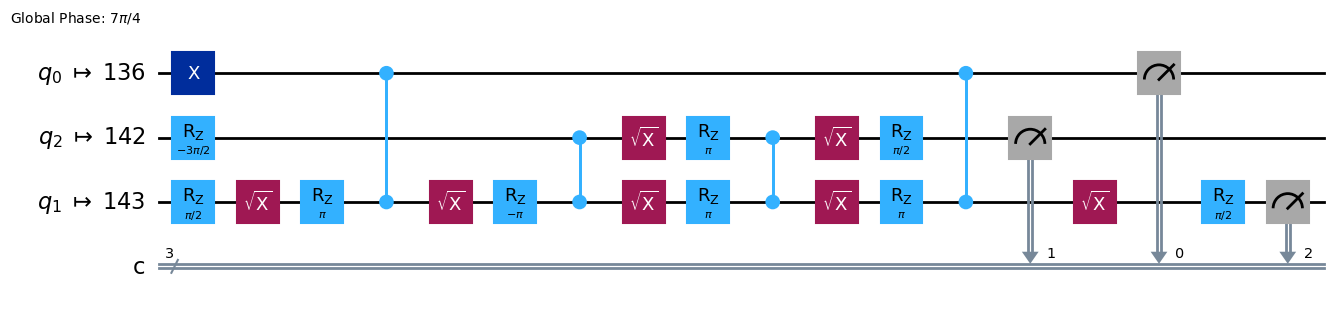

In [37]:
from qiskit import transpile
tqcq = transpile(qc, backend=backend)
tqcq.draw("mpl")

In [38]:
sv1, sv2 = verify_equivalence(qc, tqc, mapping)
sv1.draw("latex")

<IPython.core.display.Latex object>

In [39]:
sv2.draw("latex")

<IPython.core.display.Latex object>